# Análisis exploratorio de Baskonia en la Euroliga

## Continuidad de plantilla y rendimiento deportivo entre 2016-17 y 2025-26

**autor:** Roberto Cantero  
**proyecto:** Nebula

### Objetivo

Explorar las estadísticas individuales de los jugadores de Baskonia y medir cuánto cambia la producción del equipo entre temporadas.

### Pregunta principal

¿Existe alguna relación entre la continuidad de la producción anotadora y el rendimiento deportivo de Baskonia?

### Importo las librerías necesarias

In [1]:
# importo las librerías que voy a utilizar durante el análisis
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Recupero el dataset preparado

In [2]:
# localizo la carpeta principal del proyecto
root = Path.cwd()

# construyo la ruta del dataset que preparé en el notebook anterior
players_file = (
    root
    / "data"
    / "processed"
    / "baskonia_players_2016_2026.csv"
)

# cargo los datos y conservo los identificadores como texto
df_players = pd.read_csv(
    players_file,
    dtype={"player_id": str}
)

print("Archivo cargado:", players_file)
print("Dimensiones:", df_players.shape)

df_players.head()

Archivo cargado: c:\Users\rober\OneDrive\Documentos\Bootcamp The Bridge\baskoniaEDA\data\processed\baskonia_players_2016_2026.csv
Dimensiones: (153, 8)


,season,season_start,player_id,player_name,games_played,minutes,points,pir
0,2016-17,2016,007200,"LARKIN, SHANE",30.0,872.616667,393.0,446.0
1,2016-17,2016,005099,"HANGA, ADAM",30.0,837.966667,317.0,406.0
2,2016-17,2016,006590,"BEAUBOIS, RODRIGUE",27.0,550.083333,314.0,219.0
3,2016-17,2016,007201,"VOIGTMANN, JOHANNES",30.0,699.200000,301.0,447.0
4,2016-17,2016,001133,"SHENGELIA, TORNIKE",21.0,437.783333,224.0,248.0


### Valido el dataset

In [3]:
# compruebo que el dataset mantiene la estructura esperada
assert df_players.shape == (153, 8)

# compruebo que contiene las diez temporadas del análisis
assert df_players["season"].nunique() == 10

# compruebo que no contiene valores ausentes
assert df_players.isna().sum().sum() == 0

print("El dataset está preparado para comenzar el EDA")

El dataset está preparado para comenzar el EDA


## 1. Descripción general de los datos

Antes de estudiar la continuidad de las plantillas, analizo la distribución de los partidos, minutos, puntos y valoración de los jugadores.

In [4]:
# selecciono las variables numéricas que quiero analizar
columnas_numericas = [
    "games_played",
    "minutes",
    "points",
    "pir"
]

# calculo las principales medidas estadísticas
resumen_estadistico = (
    df_players[columnas_numericas]
    .describe()
    .transpose()
    .round(2)
)

resumen_estadistico

,count,mean,std,min,25%,50%,75%,max
games_played,153.0,22.35,10.40,1.0,13.00,26.00,30.00,37.00
minutes,153.0,425.16,286.70,0.8,165.28,424.98,659.25,986.22
points,153.0,173.66,143.39,0.0,39.00,142.00,281.00,661.00
pir,153.0,188.25,166.38,-6.0,34.00,161.00,285.00,623.00


In [5]:
# comparo la media y la mediana de cada variable
for columna in columnas_numericas:
    media = df_players[columna].mean()
    mediana = df_players[columna].median()

    print(
        f"{columna}: "
        f"media = {media:.2f}, "
        f"mediana = {mediana:.2f}"
    )

games_played: media = 22.35, mediana = 26.00
minutes: media = 425.16, mediana = 424.98
points: media = 173.66, mediana = 142.00
pir: media = 188.25, mediana = 161.00


Los resultados revelan varios patrones:
- games_played: la media es 22,35 y la mediana 26. Los jugadores con muy pocas apariciones reducen la media. Más de la mitad de los registros disputaron al menos 26 partidos.
- minutes: media y mediana son prácticamente idénticas. El centro de la distribución está alrededor de 425 minutos.
- points: la media, 173,66, es claramente superior a la mediana, 142. Un grupo reducido de grandes anotadores eleva el promedio.
- pir: ocurre algo parecido. Los jugadores con valoraciones muy elevadas desplazan la media por encima de la mediana.
Esto sugiere que puntos y valoración tienen una distribución asimétrica hacia la derecha.

## 2. Distribución de las variables individuales

Utilizo histogramas para observar cómo se reparten los partidos, minutos, puntos y valoración entre los jugadores.

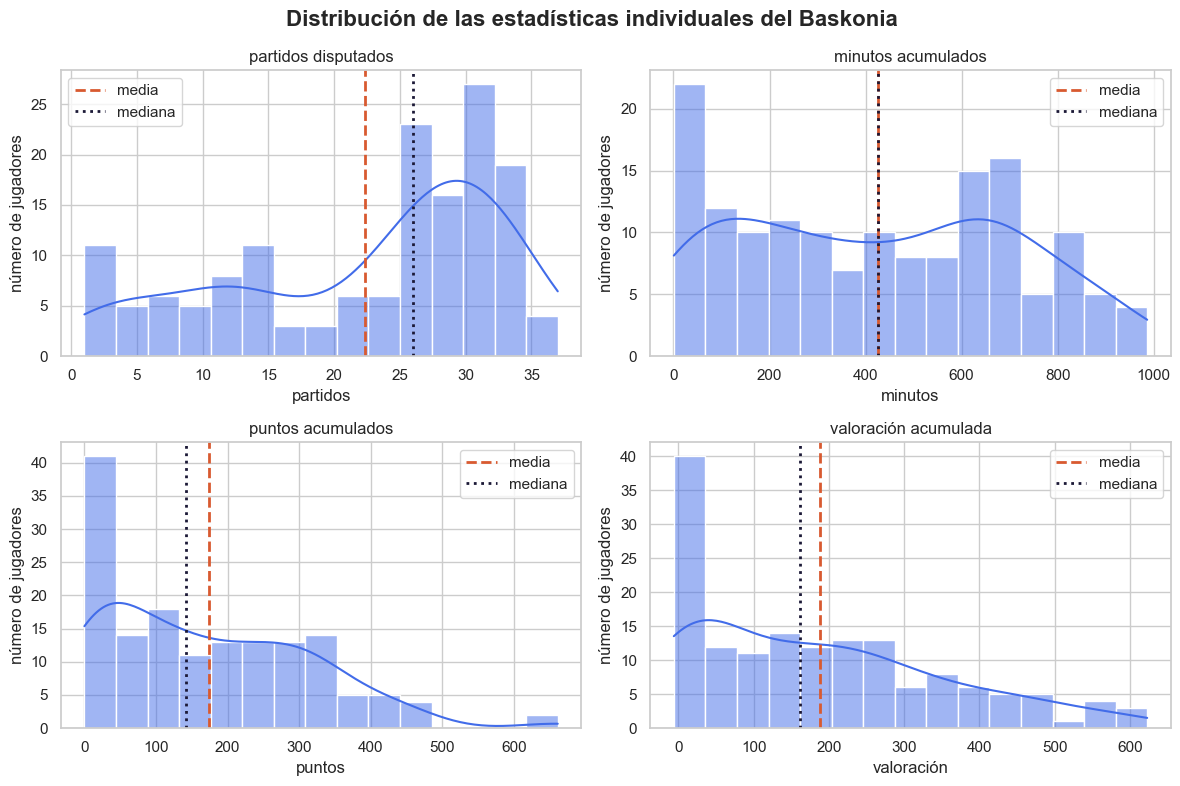

In [17]:
# aplico un estilo visual común a todos los gráficos
sns.set_theme(style="whitegrid")

# creo una figura formada por cuatro gráficos
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

# convierto la matriz de gráficos en una lista para recorrerla
axes = axes.flatten()

# defino los títulos y las etiquetas de cada variable
configuracion = {
    "games_played": ("partidos disputados", "partidos"),
    "minutes": ("minutos acumulados", "minutos"),
    "points": ("puntos acumulados", "puntos"),
    "pir": ("valoración acumulada", "valoración")
}

# creo un histograma para cada variable numérica
for eje, columna in zip(axes, columnas_numericas):
    titulo, etiqueta_x = configuracion[columna]

    sns.histplot(
        data=df_players,
        x=columna,
        bins=15,
        kde=True,
        color="#426ce9",
        ax=eje
    )

    # marco la media con una línea naranja
    eje.axvline(
        df_players[columna].mean(),
        color="#d85a30",
        linestyle="--",
        linewidth=2,
        label="media"
    )

    # marco la mediana con una línea azul oscura
    eje.axvline(
        df_players[columna].median(),
        color="#1b1836",
        linestyle=":",
        linewidth=2,
        label="mediana"
    )

    eje.set_title(titulo)
    eje.set_xlabel(etiqueta_x)
    eje.set_ylabel("número de jugadores")
    eje.legend()

# añado un título general y ajusto los espacios
fig.suptitle(
    "Distribución de las estadísticas individuales del Baskonia",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

El gráfico confirma varios patrones:
- Partidos: aparecen dos grupos. Uno formado por jugadores con pocas apariciones y otro, mucho mayor, concentrado entre 25 y 34 partidos. La mediana supera a la media porque los jugadores residuales arrastran el promedio hacia abajo.
- Minutos: también se insinúan dos perfiles. Hay muchos jugadores con una participación muy reducida y otro grupo importante alrededor de 600-750 minutos.
- Puntos: la distribución está claramente sesgada hacia la derecha. La mayoría se queda por debajo de 200 puntos y unos pocos anotadores alcanzan cifras muy superiores. Por eso la media supera a la mediana.
- Valoración: presenta una forma muy parecida a los puntos. La mayoría está en la zona baja y existe una cola prolongada hasta valores superiores a 600.
La principal conclusión provisional es que no todos los jugadores deben pesar igual cuando estudiemos la continuidad. Perder un jugador con cinco partidos no equivale a perder al máximo anotador. Por eso será más útil medir el porcentaje de puntos o minutos que abandona el equipo que limitarse a contar bajas.

### Comparar las temporadas

In [8]:
# agrupo los registros para obtener un resumen de cada temporada
resumen_temporadas = (
    df_players
    .groupby(
        ["season", "season_start"],
        as_index=False
    )
    .agg(
        jugadores=("player_id", "nunique"),
        puntos_totales=("points", "sum"),
        minutos_totales=("minutes", "sum"),
        valoracion_total=("pir", "sum"),
        maximo_partidos=("games_played", "max")
    )
)

# calculo la anotación aproximada por partido
resumen_temporadas["puntos_por_partido"] = (
    resumen_temporadas["puntos_totales"]
    / resumen_temporadas["maximo_partidos"]
)

# calculo los minutos acumulados por partido como comprobación adicional
resumen_temporadas["minutos_por_partido"] = (
    resumen_temporadas["minutos_totales"]
    / resumen_temporadas["maximo_partidos"]
)

# redondeo las variables decimales para facilitar su lectura
resumen_temporadas[
    [
        "puntos_por_partido",
        "minutos_por_partido"
    ]
] = resumen_temporadas[
    [
        "puntos_por_partido",
        "minutos_por_partido"
    ]
].round(2)

resumen_temporadas

,season,season_start,jugadores,puntos_totales,minutos_totales,valoracion_total,maximo_partidos,puntos_por_partido,minutos_por_partido
0,2016-17,2016,16,2445.0,6000.0,2627.0,30.0,81.50,200.00
1,2017-18,2017,17,2487.0,6000.0,2758.0,30.0,82.90,200.00
2,2018-19,2018,15,2456.0,6025.0,2681.0,30.0,81.87,200.83
3,2019-20,2019,16,2059.0,5600.0,2062.0,28.0,73.54,200.00
4,2020-21,2020,12,2751.0,6825.0,3183.0,34.0,80.91,200.74
5,2021-22,2021,14,2395.0,6400.0,2600.0,32.0,74.84,200.00
6,2022-23,2022,14,2949.0,6850.0,3240.0,34.0,86.74,201.47
7,2023-24,2023,15,2864.0,6825.0,3077.0,34.0,84.24,200.74
8,2024-25,2024,15,2807.0,6825.0,3061.0,34.0,82.56,200.74
9,2025-26,2025,19,3357.0,7700.0,3514.0,37.0,90.73,208.11


La tabla ha revelado un problema metodológico importante: maximo_partidos representa los partidos del jugador que más encuentros disputó, no necesariamente los partidos jugados por el equipo.
Esto afecta a 2025-26:
- El jugador con más apariciones disputó 37 partidos.
- Baskonia jugó 38.
- Dividir 3.357 puntos entre 37 infla la media hasta 90,73.
- La media correcta para estos datos es aproximadamente 88,34 puntos.
Los 208,11 minutos por partido también nos alertan de que el denominador no era correcto. Este es precisamente uno de los objetivos de un EDA: encontrar errores en nuestra propia metodología antes de continuar.

### Corregir el número de partidos

El máximo de partidos disputados por un jugador no siempre coincide con el número de encuentros del equipo. Introduzco el número de partidos representados en las estadísticas individuales de cada temporada.

In [9]:
# registro los partidos incluidos en las estadísticas individuales
partidos_por_temporada = {
    "2016-17": 30,
    "2017-18": 30,
    "2018-19": 30,
    "2019-20": 28,
    "2020-21": 34,
    "2021-22": 32,
    "2022-23": 34,
    "2023-24": 34,
    "2024-25": 34,
    "2025-26": 38
}

# incorporo el número de partidos correspondiente a cada temporada
resumen_temporadas["partidos_equipo"] = (
    resumen_temporadas["season"]
    .map(partidos_por_temporada)
)

# vuelvo a calcular los puntos utilizando los partidos del equipo
resumen_temporadas["puntos_por_partido"] = (
    resumen_temporadas["puntos_totales"]
    / resumen_temporadas["partidos_equipo"]
)

# vuelvo a calcular los minutos utilizando los partidos del equipo
resumen_temporadas["minutos_por_partido"] = (
    resumen_temporadas["minutos_totales"]
    / resumen_temporadas["partidos_equipo"]
)

# calculo las prórrogas aproximadas a partir de los minutos adicionales
resumen_temporadas["prorrogas_aproximadas"] = (
    (
        resumen_temporadas["minutos_totales"]
        - resumen_temporadas["partidos_equipo"] * 200
    )
    / 25
)

# redondeo los resultados para facilitar su lectura
resumen_temporadas[
    [
        "puntos_por_partido",
        "minutos_por_partido",
        "prorrogas_aproximadas"
    ]
] = resumen_temporadas[
    [
        "puntos_por_partido",
        "minutos_por_partido",
        "prorrogas_aproximadas"
    ]
].round(2)

resumen_temporadas[
    [
        "season",
        "partidos_equipo",
        "maximo_partidos",
        "puntos_totales",
        "puntos_por_partido",
        "minutos_por_partido",
        "prorrogas_aproximadas"
    ]
]

,season,partidos_equipo,maximo_partidos,puntos_totales,puntos_por_partido,minutos_por_partido,prorrogas_aproximadas
0,2016-17,30,30.0,2445.0,81.50,200.00,0.0
1,2017-18,30,30.0,2487.0,82.90,200.00,0.0
2,2018-19,30,30.0,2456.0,81.87,200.83,1.0
3,2019-20,28,28.0,2059.0,73.54,200.00,0.0
4,2020-21,34,34.0,2751.0,80.91,200.74,1.0
5,2021-22,32,32.0,2395.0,74.84,200.00,0.0
6,2022-23,34,34.0,2949.0,86.74,201.47,2.0
7,2023-24,34,34.0,2864.0,84.24,200.74,1.0
8,2024-25,34,34.0,2807.0,82.56,200.74,1.0
9,2025-26,38,37.0,3357.0,88.34,202.63,4.0


La tabla ya es coherente. La comprobación de minutos confirma que el número de partidos utilizado es correcto:
- Las temporadas sin prórrogas tienen exactamente 200 minutos por partido.
- Las pequeñas diferencias se explican por las prórrogas.
- En 2025-26, los cuatro periodos adicionales suman 100 minutos: \(4 \times 25\).
También aparece un primer patrón deportivo:
- Mínimo anotador: 2019-20, con 73,54 puntos por partido.
- Segundo mínimo: 2021-22, con 74,84.
- Máximo anotador: 2025-26, con 88,34.
- Desde 2022-23, Baskonia supera los 82 puntos en todas las temporadas.

### Evolución de la anotación

Comparo los puntos por partido para evitar que los cambios en la duración de la fase regular distorsionen el análisis.

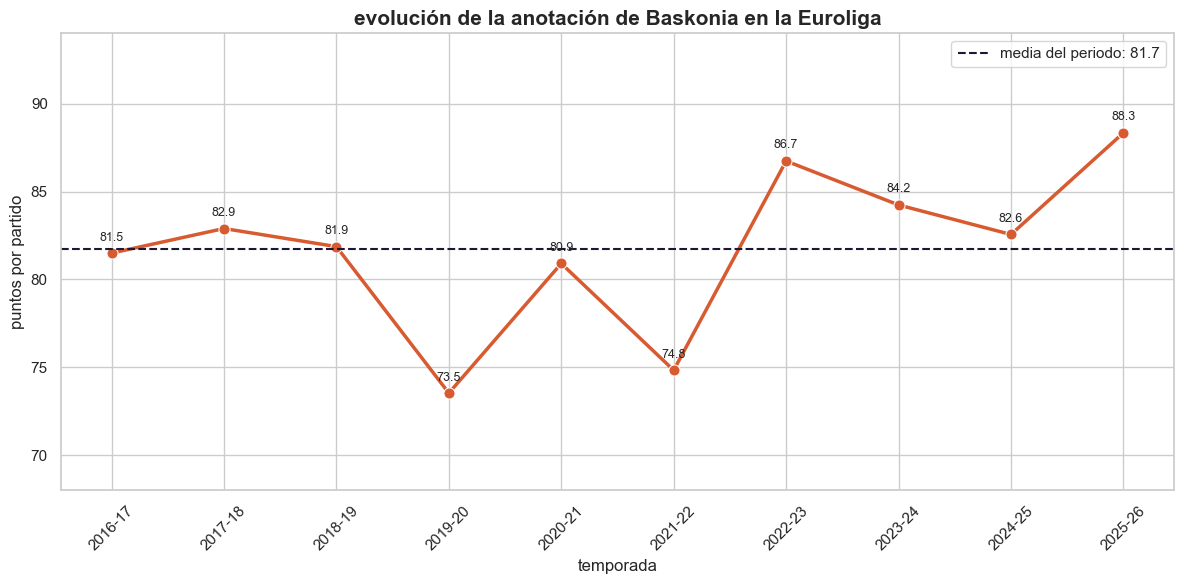

In [10]:
# creo una figura para representar la evolución de la anotación
fig, ax = plt.subplots(figsize=(12, 6))

# dibujo la línea de puntos por partido
sns.lineplot(
    data=resumen_temporadas,
    x="season",
    y="puntos_por_partido",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#d85a30",
    ax=ax
)

# añado el valor de cada temporada junto a su punto
for fila in resumen_temporadas.itertuples():
    ax.annotate(
        f"{fila.puntos_por_partido:.1f}",
        xy=(fila.season, fila.puntos_por_partido),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# añado una línea con la media de todo el periodo
media_anotacion = (
    resumen_temporadas["puntos_por_partido"]
    .mean()
)

ax.axhline(
    media_anotacion,
    color="#1b1836",
    linestyle="--",
    linewidth=1.5,
    label=f"media del periodo: {media_anotacion:.1f}"
)

# configuro los textos y límites del gráfico
ax.set_title(
    "evolución de la anotación de Baskonia en la Euroliga",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("temporada")
ax.set_ylabel("puntos por partido")
ax.set_ylim(68, 94)
ax.tick_params(axis="x", rotation=45)
ax.legend()

# ajusto los espacios para evitar que se corten las etiquetas
plt.tight_layout()

# guardo una copia del gráfico para utilizarla más adelante
plt.savefig(
    root / "exports" / "evolucion_anotacion.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

El gráfico está correctamente construido:
- Incluye las diez temporadas.
- La media del periodo es 81,7 puntos.
- El mínimo aparece en 2019-20 con 73,5.
- El segundo descenso está en 2021-22 con 74,8.
- El máximo aparece en 2025-26 con 88,3.
- Las cuatro últimas temporadas están por encima de la media del periodo.
Hay dos etapas visuales bastante claras: una primera fase irregular hasta 2021-22 y un salto ofensivo a partir de 2022-23. Todavía no sabemos qué explica ese cambio.

### Identificar al máximo anotador

Identifico al máximo anotador de cada temporada y calculo qué porcentaje de los puntos del equipo produjo.

In [11]:
# localizo el índice del jugador con más puntos en cada temporada
indices_lideres = (
    df_players
    .groupby("season")["points"]
    .idxmax()
)

# selecciono los datos de los máximos anotadores
lideres_anotadores = df_players.loc[
    indices_lideres,
    [
        "season",
        "season_start",
        "player_id",
        "player_name",
        "games_played",
        "points",
        "pir"
    ]
].copy()

# incorporo los puntos totales y los partidos de cada temporada
lideres_anotadores = lideres_anotadores.merge(
    resumen_temporadas[
        [
            "season",
            "puntos_totales",
            "partidos_equipo"
        ]
    ],
    on="season",
    how="left"
)

# calculo los puntos por partido de cada líder
lideres_anotadores["puntos_por_partido"] = (
    lideres_anotadores["points"]
    / lideres_anotadores["games_played"]
)

# calculo qué porcentaje de la anotación del equipo produjo cada líder
lideres_anotadores["peso_anotador_pct"] = (
    lideres_anotadores["points"]
    / lideres_anotadores["puntos_totales"]
    * 100
)

# ordeno la tabla cronológicamente
lideres_anotadores = (
    lideres_anotadores
    .sort_values("season_start")
    .reset_index(drop=True)
)

# redondeo las variables para facilitar su lectura
lideres_anotadores[
    [
        "puntos_por_partido",
        "peso_anotador_pct"
    ]
] = lideres_anotadores[
    [
        "puntos_por_partido",
        "peso_anotador_pct"
    ]
].round(2)

lideres_anotadores[
    [
        "season",
        "player_name",
        "games_played",
        "points",
        "puntos_por_partido",
        "peso_anotador_pct"
    ]
]

,season,player_name,games_played,points,puntos_por_partido,peso_anotador_pct
0,2016-17,"LARKIN, SHANE",30.0,393.0,13.10,16.07
1,2017-18,"SHENGELIA, TORNIKE",29.0,402.0,13.86,16.16
2,2018-19,"POIRIER, VINCENT",30.0,340.0,11.33,13.84
3,2019-20,"SHENGELIA, TORNIKE",28.0,444.0,15.86,21.56
4,2020-21,"GIEDRAITIS, ROKAS",34.0,433.0,12.74,15.74
5,2021-22,"BALDWIN IV, WADE",30.0,424.0,14.13,17.70
6,2022-23,"HOWARD, MARKUS",33.0,470.0,14.24,15.94
7,2023-24,"HOWARD, MARKUS",34.0,661.0,19.44,23.08
8,2024-25,"MONEKE, CHIMA",33.0,462.0,14.00,16.46
9,2025-26,"LUWAWU-CABARROT, TIMOTHE",36.0,657.0,18.25,19.57


La tabla muestra que la dependencia del máximo anotador no ha sido constante.
Los casos más destacados son:
- Markus Howard en 2023-24: produjo el 23,08% de los puntos, la mayor concentración de todo el periodo.
- Shengelia en 2019-20: aportó el 21,56%.
- Luwawu-Cabarrot en 2025-26: alcanzó el 19,57%.
- Poirier en 2018-19: solo representó el 13,84%, el reparto más equilibrado.
También vemos dos tipos de continuidad:
- Shengelia lideró en dos temporadas diferentes.
- Markus Howard fue el único que lideró dos temporadas consecutivas, 2022-23 y 2023-24.
Todavía no sabemos cuántos líderes permanecieron al año siguiente. Vamos a calcularlo.

### Continuidad del máximo anotador

Compruebo si el máximo anotador de cada temporada permaneció en la plantilla del curso siguiente.

In [12]:
# creo un diccionario con los jugadores presentes en cada temporada
plantillas_por_temporada = (
    df_players
    .groupby("season")["player_id"]
    .apply(set)
    .to_dict()
)

# ordeno las temporadas cronológicamente
orden_temporadas = (
    df_players[
        [
            "season",
            "season_start"
        ]
    ]
    .drop_duplicates()
    .sort_values("season_start")["season"]
    .tolist()
)

# preparo una lista para guardar cada transición entre temporadas
continuidad_lideres = []

# recorro todas las temporadas excepto la última
for posicion in range(len(orden_temporadas) - 1):
    temporada_actual = orden_temporadas[posicion]
    temporada_siguiente = orden_temporadas[posicion + 1]

    # recupero al máximo anotador de la temporada actual
    lider = lideres_anotadores[
        lideres_anotadores["season"] == temporada_actual
    ].iloc[0]

    # compruebo si su identificador aparece en la siguiente plantilla
    lider_continua = (
        lider["player_id"]
        in plantillas_por_temporada[temporada_siguiente]
    )

    # guardo el resultado de la transición
    continuidad_lideres.append(
        {
            "season": temporada_actual,
            "next_season": temporada_siguiente,
            "player_id": lider["player_id"],
            "player_name": lider["player_name"],
            "points": lider["points"],
            "peso_anotador_pct": lider["peso_anotador_pct"],
            "lider_continua": lider_continua
        }
    )

# convierto la lista de resultados en un dataframe
df_continuidad_lideres = pd.DataFrame(
    continuidad_lideres
)

df_continuidad_lideres[
    [
        "season",
        "player_name",
        "peso_anotador_pct",
        "next_season",
        "lider_continua"
    ]
]

,season,player_name,peso_anotador_pct,next_season,lider_continua
0,2016-17,"LARKIN, SHANE",16.07,2017-18,False
1,2017-18,"SHENGELIA, TORNIKE",16.16,2018-19,True
2,2018-19,"POIRIER, VINCENT",13.84,2019-20,False
3,2019-20,"SHENGELIA, TORNIKE",21.56,2020-21,False
4,2020-21,"GIEDRAITIS, ROKAS",15.74,2021-22,True
5,2021-22,"BALDWIN IV, WADE",17.70,2022-23,False
6,2022-23,"HOWARD, MARKUS",15.94,2023-24,True
7,2023-24,"HOWARD, MARKUS",23.08,2024-25,True
8,2024-25,"MONEKE, CHIMA",16.46,2025-26,False


La tabla confirma una rotación elevada en la principal referencia ofensiva:
- 5 de los 9 máximos anotadores abandonaron el equipo al terminar la temporada.
- Solo 4 continuaron.
- Baskonia perdió al líder en el 55,6% de las transiciones analizadas.
- La salida más importante por peso anotador fue la de Shengelia tras 2019-20: concentraba el 21,56% de los puntos.
Pero medir solo al líder es insuficiente. En un mismo verano pueden marcharse varios jugadores importantes. Ahora calcularemos el porcentaje total de puntos y minutos que desaparece de una temporada a la siguiente.

### Mido la producción ofensiva perdida entre temporadas

Calculo qué porcentaje de los puntos y minutos de una temporada pertenecía a jugadores que no continuaron en la siguiente.

In [13]:
# preparo una lista para guardar los resultados de cada transición
produccion_perdida = []

# recorro cada pareja de temporadas consecutivas
for posicion in range(len(orden_temporadas) - 1):
    temporada_anterior = orden_temporadas[posicion]
    temporada_actual = orden_temporadas[posicion + 1]

    # selecciono la plantilla de la temporada anterior
    plantilla_anterior = df_players[
        df_players["season"] == temporada_anterior
    ].copy()

    # selecciono la plantilla de la temporada actual
    plantilla_actual = df_players[
        df_players["season"] == temporada_actual
    ].copy()

    # creo el conjunto de jugadores presentes en la temporada actual
    jugadores_actuales = set(
        plantilla_actual["player_id"]
    )

    # identifico a los jugadores que no continuaron
    jugadores_salientes = plantilla_anterior[
        ~plantilla_anterior["player_id"].isin(
            jugadores_actuales
        )
    ].copy()

    # calculo la producción total de la temporada anterior
    puntos_totales_anteriores = (
        plantilla_anterior["points"].sum()
    )
    minutos_totales_anteriores = (
        plantilla_anterior["minutes"].sum()
    )

    # calculo la producción de los jugadores salientes
    puntos_perdidos = (
        jugadores_salientes["points"].sum()
    )
    minutos_perdidos = (
        jugadores_salientes["minutes"].sum()
    )

    # guardo las métricas de la transición
    produccion_perdida.append(
        {
            "from_season": temporada_anterior,
            "season": temporada_actual,
            "jugadores_salientes": len(
                jugadores_salientes
            ),
            "puntos_perdidos": puntos_perdidos,
            "puntos_perdidos_pct": (
                puntos_perdidos
                / puntos_totales_anteriores
                * 100
            ),
            "minutos_perdidos_pct": (
                minutos_perdidos
                / minutos_totales_anteriores
                * 100
            )
        }
    )

# convierto los resultados en un dataframe
df_produccion_perdida = pd.DataFrame(
    produccion_perdida
)

# redondeo los porcentajes para facilitar su lectura
df_produccion_perdida[
    [
        "puntos_perdidos_pct",
        "minutos_perdidos_pct"
    ]
] = df_produccion_perdida[
    [
        "puntos_perdidos_pct",
        "minutos_perdidos_pct"
    ]
].round(2)

df_produccion_perdida

,from_season,season,jugadores_salientes,puntos_perdidos,puntos_perdidos_pct,minutos_perdidos_pct
0,2016-17,2017-18,12,1486.0,60.78,64.97
1,2017-18,2018-19,7,673.0,27.06,26.92
2,2018-19,2019-20,8,1224.0,49.84,50.14
3,2019-20,2020-21,10,1364.0,66.25,62.90
4,2020-21,2021-22,7,1807.0,65.69,64.69
5,2021-22,2022-23,7,1266.0,52.86,50.11
6,2022-23,2023-24,7,1313.0,44.52,48.61
7,2023-24,2024-25,9,1298.0,45.32,55.80
8,2024-25,2025-26,9,1381.0,49.20,48.62


Este es uno de los resultados más sólidos del análisis.

Primera interpretación
- Baskonia perdió más del 60% de los puntos en tres transiciones: 2017-18, 2020-21 y 2021-22.
- El mayor cambio se produjo al llegar a 2020-21: desapareció el 66,25% de la anotación anterior.
- La mayor continuidad se registró al llegar a 2018-19: solo se perdió el 27,06%.
- En la transición hacia 2025-26 se perdió prácticamente la mitad de la anotación anterior: 49,20%.
- Los porcentajes de puntos y minutos suelen ser parecidos, lo que aporta coherencia al cálculo.
La transición hacia 2024-25 es particular: se perdió el 55,80% de los minutos, pero solo el 45,32% de los puntos. Esto indica que los jugadores que continuaron concentraban más capacidad anotadora que tiempo de juego.

### Resumir y visualizar la reconstrucción

Resumo la producción perdida y represento qué porcentaje de la anotación se conserva o desaparece cada verano.

In [14]:
# calculo el porcentaje de puntos que permaneció en el equipo
df_produccion_perdida["puntos_retenidos_pct"] = (
    100
    - df_produccion_perdida["puntos_perdidos_pct"]
)

# calculo los principales indicadores del periodo
media_puntos_perdidos = (
    df_produccion_perdida["puntos_perdidos_pct"]
    .mean()
)

mediana_puntos_perdidos = (
    df_produccion_perdida["puntos_perdidos_pct"]
    .median()
)

media_minutos_perdidos = (
    df_produccion_perdida["minutos_perdidos_pct"]
    .mean()
)

transiciones_mayores_50 = (
    df_produccion_perdida["puntos_perdidos_pct"]
    > 50
).sum()

print(
    f"media de puntos perdidos: "
    f"{media_puntos_perdidos:.2f}%"
)

print(
    f"mediana de puntos perdidos: "
    f"{mediana_puntos_perdidos:.2f}%"
)

print(
    f"media de minutos perdidos: "
    f"{media_minutos_perdidos:.2f}%"
)

print(
    f"transiciones con más del 50% de puntos perdidos: "
    f"{transiciones_mayores_50} de "
    f"{len(df_produccion_perdida)}"
)

media de puntos perdidos: 51.28%
mediana de puntos perdidos: 49.84%
media de minutos perdidos: 52.53%
transiciones con más del 50% de puntos perdidos: 4 de 9


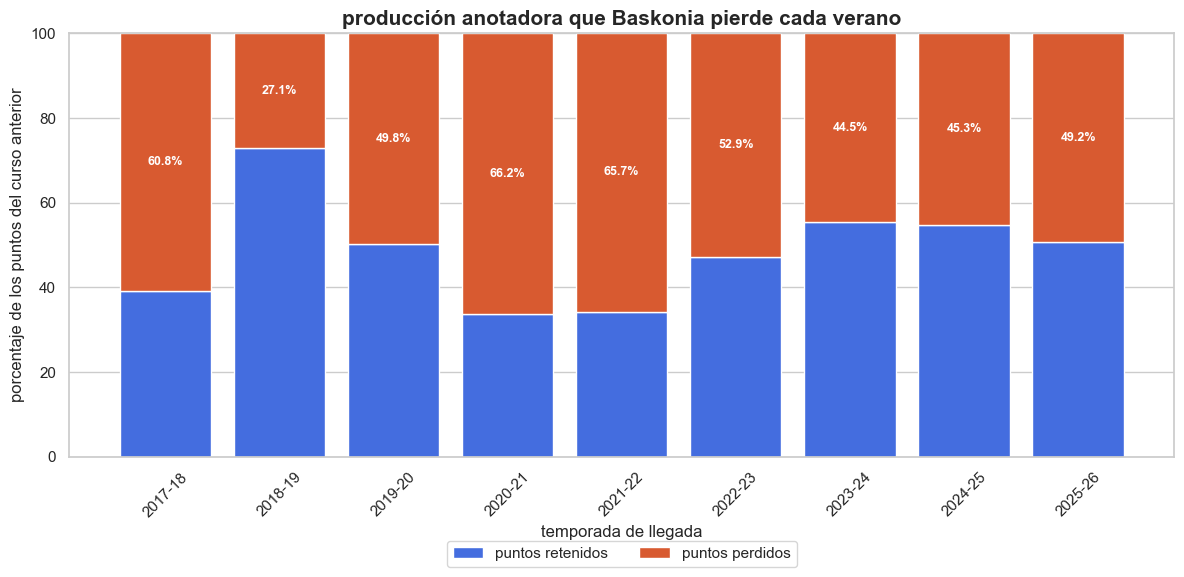

In [16]:
# creo una figura para comparar la producción retenida y perdida
fig, ax = plt.subplots(figsize=(12, 6))

# dibujo el porcentaje de puntos que permaneció
ax.bar(
    df_produccion_perdida["season"],
    df_produccion_perdida["puntos_retenidos_pct"],
    color="#446ddf",
    label="puntos retenidos"
)

# dibujo encima el porcentaje de puntos que desapareció
ax.bar(
    df_produccion_perdida["season"],
    df_produccion_perdida["puntos_perdidos_pct"],
    bottom=df_produccion_perdida["puntos_retenidos_pct"],
    color="#d85a30",
    label="puntos perdidos"
)

# añado el porcentaje perdido dentro de cada barra
for fila in df_produccion_perdida.itertuples():
    posicion_vertical = (
        fila.puntos_retenidos_pct
        + fila.puntos_perdidos_pct / 2
    )

    ax.text(
        fila.season,
        posicion_vertical,
        f"{fila.puntos_perdidos_pct:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=9
    )

# configuro los textos y los límites del gráfico
ax.set_title(
    "producción anotadora que Baskonia pierde cada verano",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("temporada de llegada")
ax.set_ylabel("porcentaje de los puntos del curso anterior")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2
)

# ajusto los espacios y guardo el gráfico
plt.tight_layout()

plt.savefig(
    root / "exports" / "produccion_perdida.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Las barras permiten ver que:
- Solo una transición conserva claramente más de dos tercios de la anotación: 2018-19.
- En tres temporadas, la parte perdida ocupa aproximadamente dos tercios de la barra.
- En los cuatro últimos veranos, la renovación se estabiliza alrededor del 45%-53%.
- No existe ninguna transición con menos de un 25% de puntos perdidos.
Visualmente, el dato central queda claro: Baskonia debe reemplazar aproximadamente la mitad de su producción casi cada verano.

### Comprobar la relación entre reconstrucción y anotación

Cruzo el porcentaje de puntos perdidos durante el verano con la anotación por partido de la temporada siguiente.

In [18]:
# incorporo la anotación de la nueva temporada a cada transición
df_continuidad_ataque = (
    df_produccion_perdida
    .merge(
        resumen_temporadas[
            [
                "season",
                "puntos_por_partido"
            ]
        ],
        on="season",
        how="left"
    )
)

# calculo la correlación lineal entre ambas variables
correlacion_pearson = (
    df_continuidad_ataque[
        "puntos_perdidos_pct"
    ]
    .corr(
        df_continuidad_ataque[
            "puntos_por_partido"
        ]
    )
)

# convierto los valores en rangos para calcular la correlación de spearman
rango_produccion_perdida = (
    df_continuidad_ataque[
        "puntos_perdidos_pct"
    ]
    .rank()
)

rango_anotacion = (
    df_continuidad_ataque[
        "puntos_por_partido"
    ]
    .rank()
)

# calculo la relación monotónica entre los rangos
correlacion_spearman = (
    rango_produccion_perdida
    .corr(rango_anotacion)
)

print(
    f"correlación de pearson: "
    f"{correlacion_pearson:.3f}"
)

print(
    f"correlación de spearman: "
    f"{correlacion_spearman:.3f}"
)

df_continuidad_ataque[
    [
        "from_season",
        "season",
        "puntos_perdidos_pct",
        "puntos_por_partido"
    ]
]

correlación de pearson: -0.249
correlación de spearman: -0.300


,from_season,season,puntos_perdidos_pct,puntos_por_partido
0,2016-17,2017-18,60.78,82.90
1,2017-18,2018-19,27.06,81.87
2,2018-19,2019-20,49.84,73.54
3,2019-20,2020-21,66.25,80.91
4,2020-21,2021-22,65.69,74.84
5,2021-22,2022-23,52.86,86.74
6,2022-23,2023-24,44.52,84.24
7,2023-24,2024-25,45.32,82.56
8,2024-25,2025-26,49.20,88.34


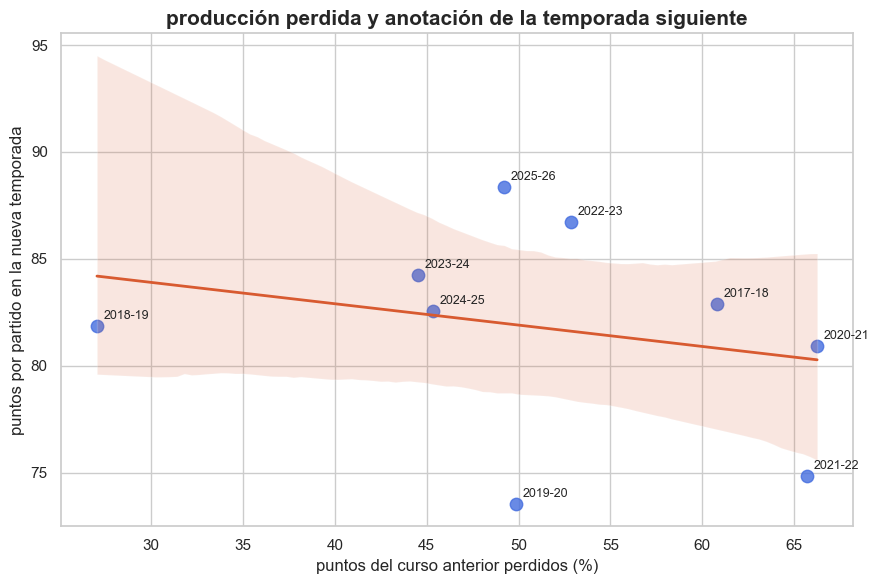

In [20]:
# creo un gráfico de dispersión con una línea de tendencia
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=df_continuidad_ataque,
    x="puntos_perdidos_pct",
    y="puntos_por_partido",
    scatter_kws={
        "s": 80,
        "color": "#446ddf"
    },
    line_kws={
        "color": "#d85a30",
        "linewidth": 2
    },
    ax=ax
)

# identifico cada punto con su temporada de llegada
for fila in df_continuidad_ataque.itertuples():
    ax.annotate(
        fila.season,
        xy=(
            fila.puntos_perdidos_pct,
            fila.puntos_por_partido
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# configuro los textos del gráfico
ax.set_title(
    "producción perdida y anotación de la temporada siguiente",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel(
    "puntos del curso anterior perdidos (%)"
)
ax.set_ylabel(
    "puntos por partido en la nueva temporada"
)

# ajusto los espacios y guardo el gráfico
plt.tight_layout()

plt.savefig(
    root
    / "exports"
    / "produccion_perdida_vs_anotacion.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

El gráfico indica una relación negativa débil: la línea desciende ligeramente, pero los puntos están muy dispersos y la zona de incertidumbre es amplia. Perder más producción no parece conducir automáticamente a una peor anotación.
Hay ejemplos claros:
- En 2020-21 se perdió el 66,25% y el equipo anotó 80,91 puntos.
- En 2021-22 se perdió casi lo mismo, 65,69%, pero la anotación bajó a 74,84.
- En 2025-26 se perdió el 49,20% y se alcanzó el máximo ofensivo.
Sin embargo, antes de profundizar debemos corregir otra limitación: hasta ahora calculamos la anotación sumando los puntos individuales. Para estudiar el rendimiento es mejor descargar la clasificación oficial, que contiene partidos, victorias, derrotas y puntos del equipo. Esto resolverá también la anomalía de 2021-22.

### Resultados oficiales del equipo

Descargo la clasificación final de cada temporada para incorporar los partidos, las victorias, las derrotas, la posición y los puntos oficiales de Baskonia.

In [21]:
# importo la herramienta que permite consultar las clasificaciones
from euroleague_api.standings import Standings

# creo el cliente para consultar la Euroliga
standings_client = Standings(
    competition="E"
)


c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# registro la última jornada disponible de cada fase regular
rondas_finales = {
    2016: 30,
    2017: 30,
    2018: 30,
    2019: 28,
    2020: 34,
    2021: 34,
    2022: 34,
    2023: 34,
    2024: 34,
    2025: 38
}

In [24]:
# defino los años de inicio de las temporadas que voy a analizar
seasons = list(
    range(2016, 2026)
)

# compruebo que he creado las diez temporadas esperadas
print(seasons)

[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [25]:
# preparo una lista para guardar los resultados de Baskonia
resultados_baskonia = []

# recorro las diez temporadas del análisis
for year in seasons:
    season_name = f"{year}-{str(year + 1)[-2:]}"

    # descargo la clasificación de la última jornada
    clasificacion = standings_client.get_standings(
        season=year,
        round_number=rondas_finales[year]
    )

    # selecciono únicamente la fila de Baskonia
    baskonia = clasificacion[
        clasificacion["club.code"] == "BAS"
    ].copy()

    # compruebo que la consulta devuelve exactamente una fila
    if len(baskonia) != 1:
        raise ValueError(
            f"no he encontrado una única fila para {season_name}"
        )

    # recupero la fila para extraer sus valores
    fila = baskonia.iloc[0]

    # guardo las variables deportivas de la temporada
    resultados_baskonia.append(
        {
            "season": season_name,
            "season_start": year,
            "games": fila["gamesPlayed"],
            "wins": fila["gamesWon"],
            "losses": fila["gamesLost"],
            "position": fila["position"],
            "points_for": fila["pointsFor"],
            "points_against": fila["pointsAgainst"]
        }
    )

    print(
        f"{season_name}: "
        f"{fila['gamesWon']} victorias, "
        f"{fila['gamesLost']} derrotas"
    )

2016-17: 17 victorias, 13 derrotas
2017-18: 16 victorias, 14 derrotas
2018-19: 15 victorias, 15 derrotas
2019-20: 12 victorias, 16 derrotas
2020-21: 18 victorias, 16 derrotas
2021-22: 12 victorias, 16 derrotas
2022-23: 18 victorias, 16 derrotas
2023-24: 18 victorias, 16 derrotas
2024-25: 14 victorias, 20 derrotas
2025-26: 13 victorias, 25 derrotas


In [26]:
# convierto los resultados descargados en un dataframe
df_resultados = pd.DataFrame(
    resultados_baskonia
)

# calculo el porcentaje de victorias
df_resultados["win_pct"] = (
    df_resultados["wins"]
    / df_resultados["games"]
    * 100
)

# calculo los puntos oficiales por partido
df_resultados["points_per_game"] = (
    df_resultados["points_for"]
    / df_resultados["games"]
)

# redondeo los porcentajes y las medias
df_resultados[
    [
        "win_pct",
        "points_per_game"
    ]
] = df_resultados[
    [
        "win_pct",
        "points_per_game"
    ]
].round(2)

df_resultados

,season,season_start,games,wins,losses,position,points_for,points_against,win_pct,points_per_game
0,2016-17,2016,30,17,13,7,2445,2376,56.67,81.50
1,2017-18,2017,30,16,14,7,2487,2373,53.33,82.90
2,2018-19,2018,30,15,15,7,2449,2378,50.00,81.63
3,2019-20,2019,28,12,16,13,2059,2155,42.86,73.54
4,2020-21,2020,34,18,16,10,2742,2619,52.94,80.65
5,2021-22,2021,28,12,16,9,2116,2186,42.86,75.57
6,2022-23,2022,34,18,16,9,2919,2836,52.94,85.85
7,2023-24,2023,34,18,16,8,2847,2865,52.94,83.74
8,2024-25,2024,34,14,20,14,2795,2830,41.18,82.21
9,2025-26,2025,38,13,25,18,3321,3483,34.21,87.39



La tabla es correcta y contiene un hallazgo llamativo: en 2025-26 Baskonia registra la mejor anotación del periodo, 87,39 puntos, pero también el peor porcentaje de victorias, 34,21%, y la peor posición, 18.º. Esto sugiere que anotar más no garantiza competir mejor. Más adelante estudiaremos los puntos recibidos.

También se confirma la anomalía de 2021-22:

Estadísticas individuales: 32 partidos y 2.395 puntos.
Clasificación oficial: 28 partidos y 2.116 puntos.
La clasificación eliminó los encuentros frente a los clubes rusos, pero las estadísticas individuales los conservaron.

In [27]:
# guardo los resultados oficiales para no tener que descargarlos otra vez
df_resultados.to_csv(
    root
    / "data"
    / "processed"
    / "baskonia_results_2016_2026.csv",
    index=False,
    encoding="utf-8"
)

print("Resultados guardados correctamente")

Resultados guardados correctamente


### Uno la continuidad en la plantilla con los resultados

In [28]:
# uno la producción perdida con los resultados oficiales
df_analisis = df_produccion_perdida.merge(
    df_resultados[
        [
            "season",
            "wins",
            "losses",
            "position",
            "win_pct",
            "points_per_game"
        ]
    ],
    on="season",
    how="left"
)

# muestro únicamente las columnas principales
df_analisis[
    [
        "season",
        "puntos_perdidos_pct",
        "wins",
        "losses",
        "position",
        "win_pct",
        "points_per_game"
    ]
]

,season,puntos_perdidos_pct,wins,losses,position,win_pct,points_per_game
0,2017-18,60.78,16,14,7,53.33,82.90
1,2018-19,27.06,15,15,7,50.00,81.63
2,2019-20,49.84,12,16,13,42.86,73.54
3,2020-21,66.25,18,16,10,52.94,80.65
4,2021-22,65.69,12,16,9,42.86,75.57
5,2022-23,52.86,18,16,9,52.94,85.85
6,2023-24,44.52,18,16,8,52.94,83.74
7,2024-25,45.32,14,20,14,41.18,82.21
8,2025-26,49.20,13,25,18,34.21,87.39


### Cálculo de correlación con victorias

In [29]:
# calculo la correlación entre los puntos perdidos y el porcentaje de victorias
correlacion_pearson = (
    df_analisis["puntos_perdidos_pct"]
    .corr(df_analisis["win_pct"])
)

# calculo la correlación utilizando el orden de los valores
correlacion_spearman = (
    df_analisis["puntos_perdidos_pct"]
    .rank()
    .corr(
        df_analisis["win_pct"].rank()
    )
)

print(
    f"correlación de pearson: "
    f"{correlacion_pearson:.3f}"
)

print(
    f"correlación de spearman: "
    f"{correlacion_spearman:.3f}"
)

correlación de pearson: 0.078
correlación de spearman: 0.298


Los resultados no respaldan la hipótesis inicial.
- Pearson 0,078: está prácticamente en cero. No existe una relación lineal clara entre perder producción anotadora y ganar menos partidos.
- Spearman 0,298: indica una relación positiva débil. En algunas temporadas, perder más producción coincide incluso con un porcentaje de victorias algo mayor.
Esto no significa que perder jugadores mejore al equipo. Solo indica que, en estas nueve transiciones, la rotación no explica por sí sola los resultados.
Además, la muestra es muy pequeña y hay otros factores: calidad de los fichajes, entrenador, lesiones, defensa, presupuesto y nivel de los rivales.

### Represento la relación

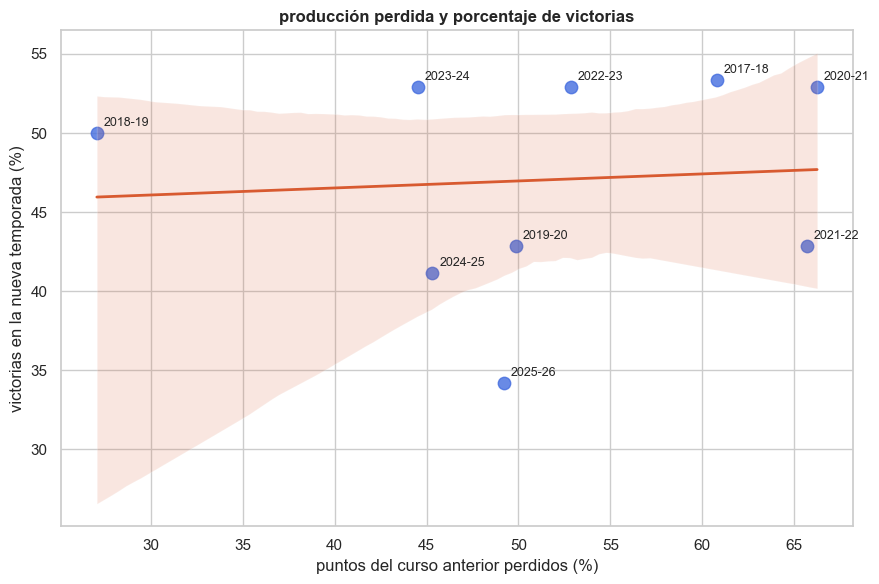

In [35]:
# represento la producción perdida y el porcentaje de victorias
fig, ax = plt.subplots(
    figsize=(9, 6)
)

sns.regplot(
    data=df_analisis,
    x="puntos_perdidos_pct",
    y="win_pct",
    scatter_kws={
        "s": 80,
        "color": "#446ddf"
    },
    line_kws={
        "color": "#d85a30",
        "linewidth": 2
    },
    ax=ax
)

# identifico cada punto con su temporada
for fila in df_analisis.itertuples():
    ax.annotate(
        fila.season,
        (
            fila.puntos_perdidos_pct,
            fila.win_pct
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# añado los títulos y las etiquetas
ax.set_title(
    "producción perdida y porcentaje de victorias",
    fontweight="bold"
)
ax.set_xlabel(
    "puntos del curso anterior perdidos (%)"
)
ax.set_ylabel(
    "victorias en la nueva temporada (%)"
)

plt.tight_layout()
plt.show()

El gráfico confirma la interpretación:
- La línea es casi horizontal.
- La ligera inclinación positiva es muy pequeña.
- La zona sombreada es muy amplia, lo que refleja mucha incertidumbre.
- Con pérdidas cercanas al 50% aparecen temporadas muy distintas: 2019-20 tuvo un 42,86% de victorias, mientras que 2025-26 cayó al 34,21%.
- En 2020-21 se perdió un 66,25% de los puntos anteriores y, aun así, se alcanzó un 52,94% de victorias.
Conclusión provisional:
Baskonia reconstruye gran parte de su anotación casi todos los veranos, pero esa rotación no explica por sí sola el porcentaje de victorias.

Ahora debemos investigar por qué una temporada con mucha anotación, como 2025-26, terminó con tan pocas victorias. El siguiente candidato es la defensa.

### Calcular los puntos recibidos

In [32]:
# calculo los puntos recibidos por partido
df_resultados["points_against_per_game"] = (
    df_resultados["points_against"]
    / df_resultados["games"]
)

# calculo la diferencia media entre puntos anotados y recibidos
df_resultados["point_diff_per_game"] = (
    (
        df_resultados["points_for"]
        - df_resultados["points_against"]
    )
    / df_resultados["games"]
)

# redondeo los resultados para facilitar su lectura
df_resultados[
    [
        "points_against_per_game",
        "point_diff_per_game"
    ]
] = df_resultados[
    [
        "points_against_per_game",
        "point_diff_per_game"
    ]
].round(2)

df_resultados[
    [
        "season",
        "points_per_game",
        "points_against_per_game",
        "point_diff_per_game",
        "win_pct",
        "position"
    ]
]

,season,points_per_game,points_against_per_game,point_diff_per_game,win_pct,position
0,2016-17,81.50,79.20,2.30,56.67,7
1,2017-18,82.90,79.10,3.80,53.33,7
2,2018-19,81.63,79.27,2.37,50.00,7
3,2019-20,73.54,76.96,-3.43,42.86,13
4,2020-21,80.65,77.03,3.62,52.94,10
5,2021-22,75.57,78.07,-2.50,42.86,9
6,2022-23,85.85,83.41,2.44,52.94,9
7,2023-24,83.74,84.26,-0.53,52.94,8
8,2024-25,82.21,83.24,-1.03,41.18,14
9,2025-26,87.39,91.66,-4.26,34.21,18


La tabla muestra una explicación mucho más clara:
- En 2025-26 Baskonia consiguió su mejor anotación, 87,39 puntos.
- Pero también recibió 91,66 puntos, el peor dato de todo el periodo.
- Su diferencia fue de -4,26 puntos por partido, también la peor.
- Las temporadas con diferencia positiva suelen tener porcentajes de victorias cercanos o superiores al 50%.
- Las temporadas con diferencia negativa presentan peores resultados, con la excepción parcial de 2023-24.
Por tanto, el problema de 2025-26 no parece ofensivo. Baskonia anotó mucho, pero recibió todavía más.

### Mido qué variables están más relacionadas con las victorias

In [33]:
# calculo la relación de cada variable con el porcentaje de victorias
correlaciones_victorias = (
    df_resultados[
        [
            "points_per_game",
            "points_against_per_game",
            "point_diff_per_game",
            "win_pct"
        ]
    ]
    .corr()["win_pct"]
    .drop("win_pct")
    .round(3)
)

correlaciones_victorias

points_per_game            0.078
points_against_per_game   -0.499
point_diff_per_game        0.863
Name: win_pct, dtype: float64

Los resultados son bastante claros:
- points_per_game = 0,078: la anotación prácticamente no tiene relación con el porcentaje de victorias.
- points_against_per_game = -0,499: existe una relación negativa moderada. Cuantos más puntos recibe Baskonia, menor tiende a ser su porcentaje de victorias.
- point_diff_per_game = 0,863: existe una relación positiva muy fuerte. Cuanto mejor es la diferencia entre puntos anotados y recibidos, mayor es el porcentaje de victorias.
Esto explica 2025-26: Baskonia anotó más que nunca, pero su defensa fue todavía peor.
La diferencia de puntos no es una causa independiente, porque se construye con el marcador de los partidos. Aun así, resume mucho mejor la competitividad del equipo que la anotación por sí sola.

### Represento la relación más fuerte

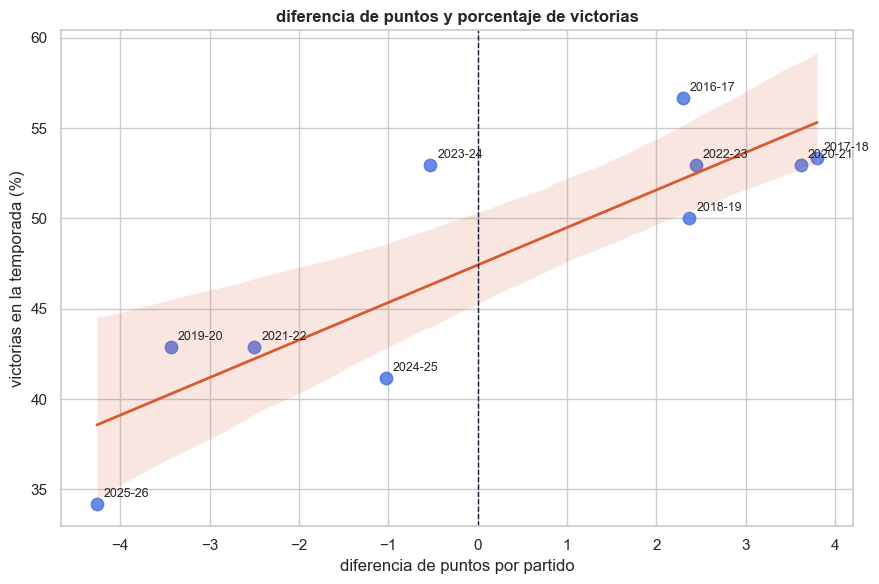

In [36]:
# represento la diferencia de puntos y el porcentaje de victorias
fig, ax = plt.subplots(
    figsize=(9, 6)
)

sns.regplot(
    data=df_resultados,
    x="point_diff_per_game",
    y="win_pct",
    scatter_kws={
        "s": 80,
        "color": "#446ddf"
    },
    line_kws={
        "color": "#d85a30",
        "linewidth": 2
    },
    ax=ax
)

# identifico cada punto con su temporada
for fila in df_resultados.itertuples():
    ax.annotate(
        fila.season,
        (
            fila.point_diff_per_game,
            fila.win_pct
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# añado una línea vertical en el equilibrio anotador
ax.axvline(
    0,
    color="#1b1836",
    linestyle="--",
    linewidth=1
)

# añado los títulos y las etiquetas
ax.set_title(
    "diferencia de puntos y porcentaje de victorias",
    fontweight="bold"
)
ax.set_xlabel(
    "diferencia de puntos por partido"
)
ax.set_ylabel(
    "victorias en la temporada (%)"
)

plt.tight_layout()
plt.show()

La relación es mucho más clara que en el gráfico de continuidad:
- Todas las temporadas con una diferencia superior a 2 puntos terminaron con al menos un 50% de victorias.
- Todas las temporadas con una diferencia inferior a -1 punto quedaron por debajo del 43%.
- 2025-26 aparece como el peor caso: -4,26 puntos y 34,21% de victorias.
- 2023-24 rindió algo mejor de lo esperado para su diferencia de puntos.
- 2024-25 rindió algo peor.

### Compruebo si conservar al líder mejora los resultados

In [37]:
# uno la continuidad del líder con los resultados de la temporada siguiente
df_lider_resultados = (
    df_continuidad_lideres
    .merge(
        df_resultados[
            [
                "season",
                "win_pct",
                "position"
            ]
        ],
        left_on="next_season",
        right_on="season",
        how="left",
        suffixes=(
            "_anterior",
            "_nueva"
        )
    )
)

# calculo el rendimiento medio según continúe o no el líder
resumen_continuidad_lider = (
    df_lider_resultados
    .groupby(
        "lider_continua",
        as_index=False
    )
    .agg(
        temporadas=("next_season", "count"),
        victorias_medias=("win_pct", "mean"),
        posicion_media=("position", "mean")
    )
    .round(2)
)

resumen_continuidad_lider

,lider_continua,temporadas,victorias_medias,posicion_media
0,False,5,47.26,11.4
1,True,4,46.74,9.5


El resultado confirma que conservar al máximo anotador no garantiza más victorias:
- Cuando el líder se marchó: 47,26% de victorias.
- Cuando continuó: 46,74%.
- La diferencia es de solo 0,52 puntos porcentuales.
La posición media sí fue algo mejor cuando continuó:
- Se marchó: 11,4.
- Continuó: 9,5.
Pero con solo nueve transiciones no podemos afirmar que conservar al líder mejore la clasificación. La evidencia es demasiado limitada.
La conclusión general empieza a ser clara: Baskonia cambia mucho su producción, pero su capacidad para reemplazarla hace que la continuidad no determine por sí sola los resultados.

In [38]:
# guardo la tabla que combina continuidad y rendimiento deportivo
df_analisis.to_csv(
    root
    / "data"
    / "processed"
    / "baskonia_continuidad_resultados.csv",
    index=False,
    encoding="utf-8"
)

print("Análisis guardado correctamente")

Análisis guardado correctamente


## Conclusiones

Baskonia perdió de media el 51,28% de los puntos producidos por la plantilla anterior en cada transición analizada. En cuatro de los nueve veranos desapareció más de la mitad de la producción anotadora.

El máximo anotador abandonó el equipo en cinco de las nueve transiciones. Sin embargo, conservarlo no se tradujo en un porcentaje mayor de victorias. Las temporadas en las que continuó terminaron con un 46,74% de victorias de media, frente al 47,26% registrado cuando se marchó.

La relación entre la producción perdida y el porcentaje de victorias es prácticamente inexistente. La correlación de Pearson es 0,078. Por tanto, los datos no respaldan la hipótesis de que una mayor renovación de plantilla provoque directamente peores resultados.

La variable más relacionada con las victorias es la diferencia entre puntos anotados y recibidos, con una correlación de 0,863. La anotación por sí sola presenta una correlación de solo 0,078, mientras que los puntos recibidos muestran una relación negativa moderada de -0,499.

La temporada 2025-26 resume esta diferencia: Baskonia consiguió la mejor anotación del periodo, con 87,39 puntos por partido, pero también recibió 91,66. Su diferencia de -4,26 puntos coincidió con el peor porcentaje de victorias, un 34,21%, y la 18.ª posición.

Los datos muestran que Baskonia vive en una reconstrucción casi permanente, pero también que ha sido capaz de reemplazar buena parte del talento perdido. El principal problema competitivo no parece ser la rotación por sí sola, sino la capacidad de construir un equipo equilibrado que no reciba más puntos de los que produce.

### Limitaciones del EDA

El análisis contiene diez temporadas y solo nueve transiciones de plantilla, por lo que la muestra es pequeña.

La temporada 2019-20 fue cancelada antes de completarse y la clasificación de 2021-22 eliminó los resultados contra los clubes rusos, aunque las estadísticas individuales conservaron esos partidos.

El análisis no incorpora otras variables relevantes, como el presupuesto, los cambios de entrenador, las lesiones, la calidad de los fichajes o la fortaleza de los rivales.

Las correlaciones describen relaciones entre variables, pero no demuestran causalidad.